<a href="https://colab.research.google.com/github/jashanchoudhary778/skin_disease_image_segmentation/blob/main/skin_image_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!df -h /content/drive/MyDrive

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   47G   66G  42% /


In [ ]:
!mkdir -p /content/drive/MyDrive/isic_data
!cp -r isic_data/* /content/drive/MyDrive/isic_data/

cp: cannot stat 'isic_data/*': No such file or directory


In [ ]:
!ls /content/drive/MyDrive/isic_data
!du -sh /content/drive/MyDrive/isic_data

4.0K	/content/drive/MyDrive/isic_data


In [ ]:
!rm -rf /content/drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/isic_data
!du -sh /content/drive/MyDrive/isic_data

ISIC2018_Task1-2_Training_Input  ISIC2018_Task1_Training_GroundTruth
11G	/content/drive/MyDrive/isic_data


In [ ]:
!du -sh /content/drive/MyDrive/isic_data
!ls /content/drive/MyDrive/isic_data/ISIC2018_Task1-2_Training_Input | wc -l
!ls /content/drive/MyDrive/isic_data/ISIC2018_Task1_Training_GroundTruth | wc -l

11G	/content/drive/MyDrive/isic_data
ls: cannot access '/content/drive/MyDrive/isic_data/ISIC2018_Task1-2_Training_Input': No such file or directory
0
ls: cannot access '/content/drive/MyDrive/isic_data/ISIC2018_Task1_Training_GroundTruth': No such file or directory
0


In [ ]:
import os

img_dir = "/content/drive/MyDrive/isic_data/ISIC2018_Task1-2_Training_Input"
mask_dir = "/content/drive/MyDrive/isic_data/ISIC2018_Task1_Training_GroundTruth"

img_files = sorted([f for f in os.listdir(img_dir) if f.endswith(".jpg")])
print(len(img_files))

2594


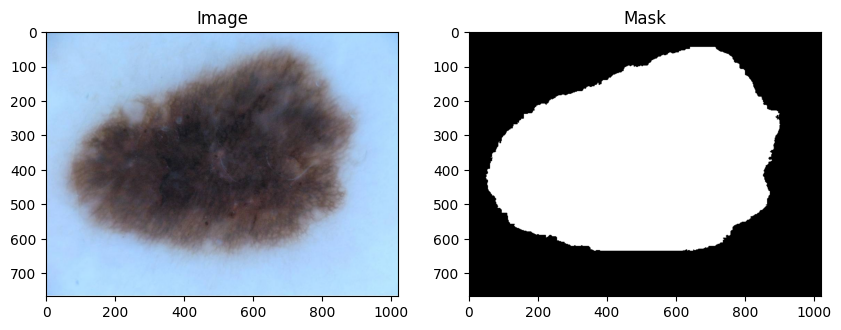

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open(f"{img_dir}/ISIC_0000000.jpg")
mask = Image.open(f"{mask_dir}/ISIC_0000000_segmentation.png")

fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].imshow(img); ax[0].set_title("Image")
ax[1].imshow(mask, cmap="gray"); ax[1].set_title("Mask")
plt.show()

In [ ]:
!pip install albumentations -q
import albumentations as A
print(A.__version__)

2.0.8


In [ ]:
import torch
from torch.utils.data import Dataset
import cv2
import numpy as np

class ISICDataset(Dataset):
    def __init__(self,img_files,img_dir,mask_dir,transform=None):
      self.transform=transform
      self.img_files=img_files
      self.img_dir=img_dir
      self.mask_dir=mask_dir

    def __len__(self):
      return len(self.img_files)

    def __getitem__(self,idx):
      img_name=self.img_files[idx]
      mask_name=img_name.replace(".jpg","_segmentation.png")

      image=cv2.imread(f"{self.img_dir}/{img_name}")
      image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

      mask=cv2.imread(f"{self.mask_dir}/{mask_name}",cv2.IMREAD_GRAYSCALE)
      mask=(mask>127).astype(np.float32)

      if self.transform:
        augmentations=self.transform(image=image,mask=mask)
        image=augmentations["image"]
        mask=augmentations["mask"]
      return image,mask

train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
])

print(train_transform)
dataset = ISICDataset(img_files, img_dir, mask_dir, transform=train_transform)
img, mask = dataset[0]
print(img.shape, mask.shape)


Compose([
  Resize(p=1.0, area_for_downscale=None, height=256, interpolation=1, mask_interpolation=0, width=256),
  HorizontalFlip(p=0.5),
  VerticalFlip(p=0.5),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)
(256, 256, 3) (256, 256)


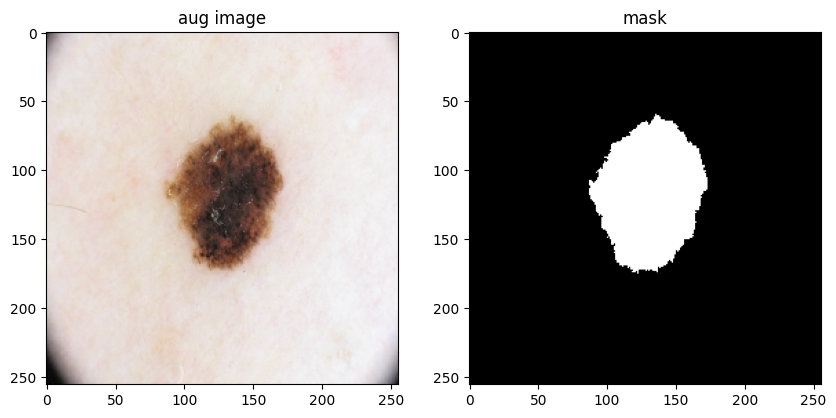

In [ ]:
dataset=ISICDataset(img_files,img_dir,mask_dir,transform=train_transform)

img,mask=dataset[122]
fig,ax=plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(img);ax[0].set_title("aug image")
ax[1].imshow(mask,cmap="gray");ax[1].set_title("mask")
plt.show()

In [ ]:
import torch
import torch.nn as nn

class ConvBlock(nn.Module):
  def __init__(self,in_channels,out_channels):
    super().__init__()
    self.conv1=nn.Conv2d(in_channels,out_channels,kernel_size=3,padding=1)
    self.relu=nn.ReLU()
    self.conv2=nn.Conv2d(out_channels,out_channels,kernel_size=3,padding=1)

  def forward(self,x):
    x=self.conv1(x)
    x=self.relu(x)
    x=self.conv2(x)
    x=self.relu(x)
    return x

block1=ConvBlock(in_channels=3,out_channels=64)
fake_input=torch.randn(1,3,256,256)
output=block1(fake_input)
print(output.shape)

pool=nn.MaxPool2d(kernel_size=2,stride=2)
output=pool(output)
print(output.shape)

block2 = ConvBlock(in_channels=64, out_channels=128)
output2 = block2(output)
print(output2.shape)

pooled_output2 = pool(output2)
print(pooled_output2.shape)

torch.Size([1, 64, 256, 256])
torch.Size([1, 64, 128, 128])
torch.Size([1, 128, 128, 128])
torch.Size([1, 128, 64, 64])


In [ ]:
class Encoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.block1=ConvBlock(3,64)
    self.block2=ConvBlock(64,128)
    self.block3=ConvBlock(128,256)
    self.block4=ConvBlock(256,512)
    self.pool=nn.MaxPool2d(kernel_size=2,stride=2)

  def forward(self,x):
    skip1=self.block1(x)
    x=self.pool(skip1)

    skip2=self.block2(x)
    x=self.pool(skip2)

    skip3=self.block3(x)
    x=self.pool(skip3)

    skip4=self.block4(x)
    x=self.pool(skip4)

    return x,[skip1,skip2,skip3,skip4]

encoder=Encoder()
fake_input=torch.randn(1,3,256,256)
bottleneck_input,skips=encoder(fake_input)


print(bottleneck_input.shape)
for i,s in enumerate(skips):
  print(f"skip{i+1}: {s.shape}")

bottleneck = ConvBlock(512, 1024)

bottleneck_output = bottleneck(bottleneck_input)
print(bottleneck_output.shape)


torch.Size([1, 512, 16, 16])
skip1: torch.Size([1, 64, 256, 256])
skip2: torch.Size([1, 128, 128, 128])
skip3: torch.Size([1, 256, 64, 64])
skip4: torch.Size([1, 512, 32, 32])
torch.Size([1, 1024, 16, 16])


In [ ]:
class UpBlock(nn.Module):
  def __init__(self,in_channels,out_channels):
    super().__init__()
    self.upconv=nn.ConvTranspose2d(in_channels,out_channels,kernel_size=2,stride=2)
    self.conv_block=ConvBlock(out_channels*2,out_channels)

  def forward(self,x,skip):
    x=self.upconv(x)
    x=torch.cat([x,skip],dim=1)
    x=self.conv_block(x)
    return x

up1=UpBlock(1024,512)
decoder_output=up1(bottleneck_output,skips[3])
print(decoder_output.shape)

up2=UpBlock(512,256)
decoder_output=up2(decoder_output,skips[2])
print(decoder_output.shape)

up3=UpBlock(256,128)
decoder_output=up3(decoder_output,skips[1])
print(decoder_output.shape)

up4 = UpBlock(128, 64)
decoder_output4 = up4(decoder_output, skips[0])  # skips[0] = skip1
print(decoder_output4.shape)

final_conv = nn.Conv2d(64, 1, kernel_size=1)

final_output = final_conv(decoder_output4)
print(final_output.shape)

torch.Size([1, 512, 32, 32])
torch.Size([1, 256, 64, 64])
torch.Size([1, 128, 128, 128])
torch.Size([1, 64, 256, 256])
torch.Size([1, 1, 256, 256])


In [ ]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.bottleneck = ConvBlock(512, 1024)

        self.up1 = UpBlock(1024, 512)
        self.up2 = UpBlock(512, 256)
        self.up3 = UpBlock(256, 128)
        self.up4 = UpBlock(128, 64)

        self.final_conv = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        x, skips = self.encoder(x)
        x = self.bottleneck(x)

        x = self.up1(x, skips[3])
        x = self.up2(x, skips[2])
        x = self.up3(x, skips[1])
        x = self.up4(x, skips[0])

        x = self.final_conv(x)
        return x


model = UNet()
fake_input = torch.randn(1, 3, 256, 256)
output = model(fake_input)
print(output.shape)


total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

torch.Size([1, 1, 256, 256])
Total parameters: 31,031,745
